<div style="
  background: linear-gradient(135deg, #ff9a9e, #fad0c4, #fbc2eb);
  padding: 28px;
  border-radius: 24px;
  text-align: center;
  color: #3a2c4a;
  box-shadow: 0 8px 20px rgba(0,0,0,0.12);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🌈 DaneshChat AI Adventure 🚀
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build Smart Models for Spam & Message Loss Detection
  </h2>

  <p style="font-size: 18px;">
    Welcome, young AI engineer! Today you will train machines to understand messages better.
  </p>

</div>

### Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay

### Load the dataset

In [3]:
# Read the CSV file named "daneshchat_logs.csv"
DATA_DIR = "Data/"
DANESHCHAT_CSV_PATH = f"{DATA_DIR}daneshchat_logs.csv"

# Store it in a variable named df
df = pd.read_csv(DANESHCHAT_CSV_PATH)

# Show the first 5 rows
df.head()

,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
0,49.73,10,0.954,0,0,0,0
1,60.27,4,0.369,0,0,0,1
2,77.18,17,0.025,0,0,0,1
3,21.13,8,0.334,1,0,1,1
4,39.09,2,0.664,0,0,0,0


### Quick data check

In [4]:
END = "\n" + "-" * 40 + "\n"
print("=" * 40)
print("\tQuick Look at the Data")
print("=" * 40)
# Print the shape of the dataset
print(f"Shape: {df.shape}", end=END)
# Print the column names
print(f"Columns: {df.columns.to_list()}", end=END)
# Check missing values
print(f"Misssing Values:\n{df.isnull().sum()}", end=END)
# Show basic statistics using describe()
print(f"Basic Statistics:")
print(df.describe())
print("=" * 40)

	Quick Look at the Data
Shape: (6000, 7)
----------------------------------------
Columns: ['message_size_kb', 'transfer_steps', 'connection_quality', 'has_urgent_keyword', 'has_link', 'is_spam', 'is_lost']
----------------------------------------
Misssing Values:
message_size_kb       0
transfer_steps        0
connection_quality    0
has_urgent_keyword    0
has_link              0
is_spam               0
is_lost               0
dtype: int64
----------------------------------------
Basic Statistics:
       message_size_kb  transfer_steps  connection_quality  \
count      6000.000000     6000.000000         6000.000000   
mean         65.794645        8.684667            0.595544   
std         121.959485        6.041494            0.266757   
min           1.000000        1.000000            0.000000   
25%          23.342500        4.000000            0.399750   
50%          40.830000        7.000000            0.644000   
75%          67.992500       12.000000            0.811250   

### Clean the dataset

In [5]:
# Remove duplicated rows
df = df.drop_duplicates()
# Convert columns to numeric if needed
numeric_cols = ['message_size_kb', 'transfer_steps', 'connection_quality', 'has_urgent_keyword', 'has_link', 'is_spam', 'is_lost']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")
# Remove rows with missing values
df = df.dropna()
# Keep only valid connection_quality values between 0 and 1
df = df[(0 <= df["connection_quality"]) & (df['connection_quality'] <= 1)]
# Keep only positive message_size_kb and transfer_steps
df = df[(df["message_size_kb"] > 0) & (df["transfer_steps"] > 0)]

print(f"Cleanded Dataset shape: f{df.shape}")
df.head()

Cleanded Dataset shape: f(6000, 7)


,message_size_kb,transfer_steps,connection_quality,has_urgent_keyword,has_link,is_spam,is_lost
0,49.73,10,0.954,0,0,0,0
1,60.27,4,0.369,0,0,0,1
2,77.18,17,0.025,0,0,0,1
3,21.13,8,0.334,1,0,1,1
4,39.09,2,0.664,0,0,0,0


<div style="
  background: linear-gradient(135deg, #74c69d, #48cae4);
  padding: 26px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #2d6a4f;
  box-shadow: 0 8px 22px rgba(0, 0, 0, 0.18);
  color: #081c15;
">

  <h1 style="
    color: #081c15;
    background-color: rgba(255, 255, 255, 0.65);
    padding: 12px 16px;
    border-radius: 14px;
    margin-top: 0;
  ">
    🌳 Part A: Build a Decision Tree from Scratch
  </h1>

  <p style="
    font-size: 17px;
    line-height: 1.7;
    color: #133f30;
    font-weight: 500;
  ">
    In this part, you will build your own Decision Tree classifier.
    You may use Python, NumPy, and Pandas, but not a ready-made Decision Tree model.
  </p>

  <pre style="
    background-color: #0f4331;
    color: #d8f3dc;
    padding: 16px;
    border-radius: 14px;
    border: 3px solid #95d5b2;
    font-size: 15px;
    line-height: 1.6;
    overflow-x: auto;
  ">Is connection_quality <= 0.45?

├── Yes: maybe lost

└── No: maybe delivered</pre>

</div>

### Create a Node class

In [6]:
class Node:
    def __init__(self, feature=None, threshold=None, left=None, right=None, value=None):
        self.feature = feature # Store the feature name used for splitting
        self.threshold = threshold # Store the threshold value
        self.left = left # Store the left child
        self.right = right # Store the right child
        self.value = value # Store the final prediction value for leaf nodes

    def is_leaf(self):
        """Return True if this node is a leaf""" 
        return self.value is not None # True if a node a prediction value

### Decision Tree Classifier from Scratch

In [7]:
class DecisionTreeClassifierScratch:
    def __init__(self, max_depth=5, min_samples_split=20, min_samples_leaf=10, binary_classifiction = True):
        self.max_depth = max_depth # Store max_depth
        self.min_samples_split = min_samples_split # Store min_samples_split
        self.min_samples_leaf = min_samples_leaf # Store min_samples_leaf
        self.root = None # Create a variable named root and set it to None
        self.binary_classifiction = binary_classifiction

    def entropy(self, y):
        """Calculate entropy using class probabilities"""
        if len(y) == 0:
            return 0.0
        
        values, counts = np.unique(y, return_counts=True)
        probabilities = counts / len(y)
        return -np.sum(probabilities * np.log2(probabilities + 1e-9))   # Add a small value to avoid log(0)

    def information_gain(self, y, y_left, y_right):
        """Info Gain = Parent Entropy - Weightened Children Entropy"""
        if len(y) == 0:
            return 0.0        
    
        # Calculate parent entropy
        parent_entropy = self.entropy(y)
        # Calculate weighted child entropy
        children_entropy = len(y_left) * self.entropy(y_left) + \
                           len(y_right) * self.entropy(y_right)
        children_entropy = children_entropy / len(y)
        # Return information gain
        return parent_entropy - children_entropy

    def majority_class(self, y):
        """Return the most common class in y"""
        values, counts = np.unique(y, return_counts=True)
        return values[np.argmax(counts)]

    def find_best_split(self, X : pd.DataFrame, y):
        """Find the best feature to split by using information gain"""
        best_gain = -np.inf
        best_feature = None
        best_threshold = None
        # Try each feature
        for feature in X.columns:
            col_values = X[feature].values
            unique_values = np.sort(np.unique(col_values))
            if len(unique_values) <= 1:
                continue
            
            # Try possible thresholds for each feature
            for threshold in unique_values:
                # Split y into left and right groups
                y_left = y[col_values <= threshold]
                y_right = y[col_values > threshold]

                if len(y_left) < self.min_samples_leaf or len(y_right) < self.min_samples_leaf:
                    continue

                # Calculate information gain
                gain = self.information_gain(y, y_left, y_right)
                if gain > best_gain:
                    best_gain = gain
                    best_feature = feature
                    best_threshold = threshold

        # Return best feature and best threshold
        return best_feature, best_threshold

    def build_tree(self, X : pd.DataFrame, y, depth=0):
        """Recursively build the decision tree and return the root Node."""
        node_value = self.majority_class(y) if self.binary_classifiction else np.mean(y == 1)

        # Check stopping conditions
        if depth >= self.max_depth or \
           len(y) < self.min_samples_split or \
           len(np.unique(y)) == 1:              # Pure node

            return Node(value=node_value)
        
        # Find the best split
        best_feature, best_threshold = self.find_best_split(X, y)
        if best_feature is None:
            return Node(value=node_value)
        
        # Build left and right child nodes recursively
        mask_left = X[best_feature].values <= best_threshold
        mask_right = X[best_feature].values > best_threshold

        X_left, y_left = X[mask_left], y[mask_left]
        X_right, y_right = X[mask_right], y[mask_right]

        left_child = self.build_tree(X_left, y_left, depth + 1)
        right_child = self.build_tree(X_right, y_right, depth + 1)
        
        # Return a Node
        return Node(feature=best_feature, threshold=best_threshold, left=left_child, right=right_child)

    def fit(self, X, y):
        """Build the tree and store it in self.root"""
        self.root = self.build_tree(X, y)

    def predict_one(self, row):
        """Traverse the tree for a single sample and return the predicted label."""
        # Start from the root
        node = self.root
        # Move left or right until reaching a leaf
        while not node.is_leaf():
            node = node.left if row[node.feature] <= node.threshold else node.right
        # Return the leaf value
        return node.value
        
    def predict(self, X : pd.DataFrame, threshold = 0.5):
        """Predict each row in X"""
        probs = np.array([self.predict_one(row) for _, row in X.iterrows()])
        return (probs >= threshold).astype(int)

### Prepare data for spam prediction

In [14]:
# Set y_spam to df["is_spam"]
y_spam = df["is_spam"]
# Set X_spam by dropping both "is_spam" and "is_lost"
X_spam = df.drop(columns=["is_spam", "is_lost"])
# Split X_spam and y_spam into train and validation sets
X_train_spam, X_test_spam, y_train_spam, y_test_spam = train_test_split(
    X_spam, y_spam, test_size=0.2, stratify=y_spam
)

print("=" * 40)
print(f"Train Size: {X_train_spam.shape}\t| Test Size: {X_test_spam.shape}")
print("=" * 40)

Train Size: (4800, 5)	| Test Size: (1200, 5)


### Train your scratch Decision Tree for spam

In [15]:
# Create a DecisionTreeClassifierScratch object
descision_tree_scratch_binary = DecisionTreeClassifierScratch(binary_classifiction=True)
# Fit it on X_train_spam and y_train_spam
descision_tree_scratch_binary.fit(X_train_spam, y_train_spam)
# Predict on X_val_spam
y_pred_scratch_binary = descision_tree_scratch_binary.predict(X_test_spam)

In [16]:
descision_tree_scratch_ratio = DecisionTreeClassifierScratch(binary_classifiction=False)
descision_tree_scratch_ratio.fit(X_train_spam, y_train_spam)

best_metric = -np.inf
for spam_detect_threshold in np.linspace(0, 1, 20):
    temp_predict = descision_tree_scratch_ratio.predict(X_test_spam, spam_detect_threshold)
    temp_f1 = f1_score(y_test_spam, temp_predict, zero_division=0)
    temp_precision = precision_score(y_test_spam, temp_predict, zero_division=0)
    temp_metric = (2 * temp_f1 * temp_precision) / (temp_f1 + temp_precision)
    if temp_metric > best_metric:
        y_pred_scratch_ratio = temp_predict.copy()
        best_metric = temp_metric
        best_threshold = spam_detect_threshold

print(f"Best Threshold to have maximum F1 Score with focus on Precision: {best_threshold:.4f}")

Best Threshold to have maximum F1 Score with focus on Precision: 0.4211


### Create an evaluation function

Model: Scratch Binary Decision Tree on Spam detection
Accuracy:	0.7067
----------------------------------------
Precision:	0.8015
----------------------------------------
Recall:		0.4225
----------------------------------------
F1 Score:	0.5533


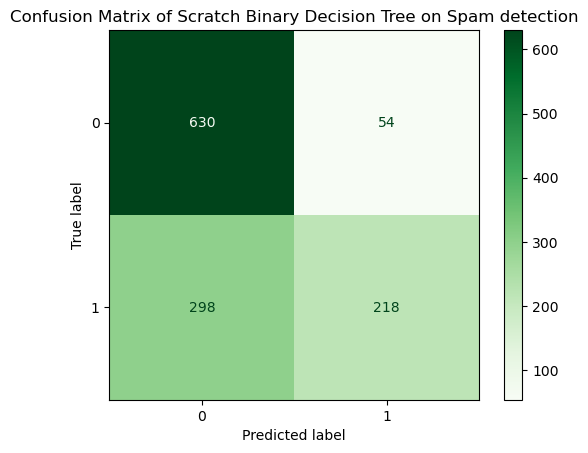

Model: Scratch Binary Ratio Tree on Spam detection
Accuracy:	0.7175
----------------------------------------
Precision:	0.7479
----------------------------------------
Recall:		0.5174
----------------------------------------
F1 Score:	0.6117


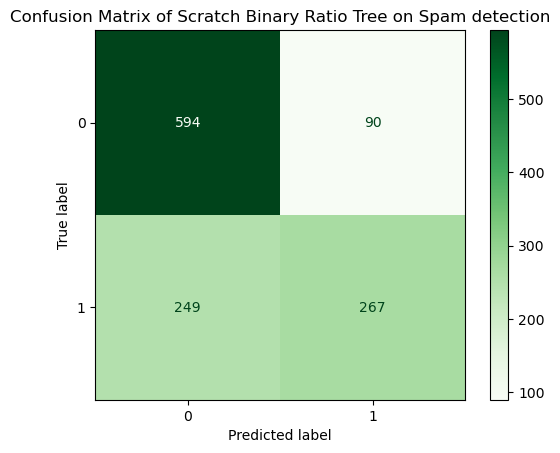

In [17]:
def evaluate_model(y_true, y_pred, model_name):
    """Print Accuracy, Precision, Recall, F1 and plot Confusion Matrix."""
    # Calculate accuracy
    accuracy = accuracy_score(y_true, y_pred)
    # Calculate precision
    precision = precision_score(y_true, y_pred, zero_division=0)
    # Calculate recall
    recall = recall_score(y_true, y_pred, zero_division=0)
    # Calculate F1-score
    f1 = f1_score(y_true, y_pred, zero_division=0)
    # Print the results in a nice format
    print("=" * 40)
    print(f"Model: {model_name}")
    print("=" * 40)
    print(f"Accuracy:\t{accuracy:.4f}", end=END)
    print(f"Precision:\t{precision:.4f}", end=END)
    print(f"Recall:\t\t{recall:.4f}", end=END)
    print(f"F1 Score:\t{f1:.4f}")
    print("=" * 40)

    confusion_mat = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_mat)
    disp.plot(cmap="Greens")
    plt.title(f"Confusion Matrix of {model_name}")
    plt.show()

evaluate_model(y_test_spam, y_pred_scratch_binary, "Scratch Binary Decision Tree on Spam detection")
evaluate_model(y_test_spam, y_pred_scratch_ratio, "Scratch Binary Ratio Tree on Spam detection")

<div style="
  background: linear-gradient(135deg, #e8b7e8, #ffb6f4);
  padding: 24px;
  border-radius: 22px;
  margin-top: 28px;
  border: 4px solid #481344;
  color: #2b0a2a;
">

  <h1 style="color: #2b0a2a;">⚡ Part B: Fast Spam Filtering with Scikit-learn</h1>

  <p style="font-size: 17px; line-height: 1.7; color: #2b0a2a;">
    Now you can use ready-made tools from Scikit-learn.
    In this part, focus only on predicting <code>is_spam</code>.
  </p>

</div>

### Train a Naive Bayes spam filter

In [ ]:
# Import GaussianNB from sklearn.naive_bayes
# Create a GaussianNB model
# Train the model using X_train_spam and y_train_spam
# Predict on X_val_spam
# Evaluate the model using Accuracy and F1-score

### Random Forest and GridSearchCV

In [ ]:
# Import RandomForestClassifier
# Import GridSearchCV
# Create a RandomForestClassifier
# Create a param_grid for different max_depth values
# Use GridSearchCV with scoring="f1"
# Fit GridSearchCV on the training data
# Print the best parameters
# Predict using the best model
# Evaluate the Random Forest model

### Final model comparison

In [ ]:
# Create a DataFrame comparing:
#       - Scratch Decision Tree
#       - Naive Bayes
#       - Random Forest
#
# Columns:
#       - Model
#       - Accuracy
#       - F1-score
#
# Display the comparison table


<div style="
  background: linear-gradient(135deg, #9668b1, #8fb5d7, #78b9f6);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🧠 Mental Wellness AI Guardian 🌿
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a Simple Neural Network from Scratch
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, wellness data scientist!  
    In this mission, you will train a small neural network to understand student habits
    and classify mental state patterns.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    💤 Sleep • 📰 News • 📱 Screen Time • 🔐 VPN Attempts • 🤖 Neural Network
  </div>

</div>

### Imports

### Logistic regression from scratch

In [ ]:
class SoftmaxRegressionScratch:
    """
    Multiclass logistic regression using softmax and gradient descent.
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000):
        """
        Initialize the model.
        Args:
            learning_rate (float): step size for gradient descent.
            n_iterations (int): number of training epochs.
        """
        ## self.lr = ...
        ## self.n_iter = ...
        self.weights = None   # shape (n_features, n_classes)
        self.bias = None      # shape (n_classes,)
        self.loss_history = []

    def _softmax(self, z):
        """
        Compute softmax probabilities for each sample.
        Args:
            z (np.ndarray): linear output, shape (n_samples, n_classes)
        Returns:
            np.ndarray: probabilities, shape (n_samples, n_classes)
        """
        # implement softmax with numerical stability
        pass

    def _one_hot(self, y, n_classes):
        """
        Convert integer labels to one-hot encoding.
        Args:
            y (np.ndarray): labels, shape (n_samples,)
            n_classes (int): number of unique classes
        Returns:
            np.ndarray: one-hot matrix, shape (n_samples, n_classes)
        """
        # implement one-hot encoding
        pass

    def fit(self, X, y):
        """
        Train the model using gradient descent.
        Args:
            X (np.ndarray): training features, shape (n_samples, n_features)
            y (np.ndarray): training labels, shape (n_samples,)
        """
        n_samples, n_features = X.shape
        n_classes = len(np.unique(y))
        
        # Initialize parameters
        # initialize self.weights (zeros) and self.bias (zeros)
        
        # One-hot encode labels
        # call self._one_hot(y, n_classes)
        
        # Gradient descent loop
        for i in range(self.n_iter):
            # Forward pass: compute linear output z, then probabilities
            # TODO
            
            # Compute cross-entropy loss (store in self.loss_history if desired)
            
            # Compute gradients
            # dw = 
            # db = 
            
            # Update parameters
            # 
            
            # print loss every 200 iterations
            if i % 200 == 0:
                print(f"Iter {i}: loss = {loss:.4f}")

    def predict_proba(self, X):
        """
        Predict class probabilities for new data.
        Args:
            X (np.ndarray): features, shape (n_samples, n_features)
        Returns:
            np.ndarray: probabilities, shape (n_samples, n_classes)
        """
        # compute linear output and apply softmax
        pass

    def predict(self, X):
        """
        Predict class labels for new data.
        Args:
            X (np.ndarray): features, shape (n_samples, n_features)
        Returns:
            np.ndarray: predicted labels, shape (n_samples,)
        """
        # get probabilities and return argmax
        pass


### Load data

In [2]:
## TODO:

### Preprocessing

In [ ]:
# Separate features (X) and target (y = mental_state)

# Split into train (80%) and validation (20%) with stratification

# Scale features using StandardScaler

### Train and evaluate custom model

In [ ]:
# custom_model = ...

# Measure training time and call fit()

# Predict on validation set and compute accuracy, classification report,
#       and confusion matrix

### Compare with sklearn's LogisticRegression

In [ ]:
# Train sklearn's LogisticRegression (multinomial, lbfgs)
# Compare training time and performance metrics

### Imbalanced Data Analysis

In [ ]:
# Print class distribution in training set
# Explain why accuracy alone is misleading
# Show macro/weighted F1 scores

<div style="
  background: linear-gradient(135deg, #7dbcf3, #9ff98d, #d6a870);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #1d3557;
  box-shadow: 0 8px 20px rgba(0,0,0,0.15);
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🏔️ Payamnouria Mountain AI Mission 🤖
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Predict Safe and Dangerous Trekking Routes
  </h2>

  <p style="font-size: 18px;">
    Welcome, young data explorer! Today you will help hikers choose safer mountain paths.
  </p>

</div>

### Imports

In [ ]:

# TODO:

### Load the dataset

In [ ]:
CSV_PATH = "trekking_expedition.csv"

# Read the CSV file into a DataFrame named df
# Print the shape of the dataset
# Display the first 5 rows

### Basic cleaning

In [ ]:
required_columns = [
    "slope_angle",
    "wolf_prob",
    "rain_mm",
    "cold_resistance",
    "is_safe"
]

# Check that all required columns exist in df

# Remove duplicate rows

# Convert these columns to numeric:
#       slope_angle, wolf_prob, rain_mm, is_safe

# Remove rows with missing values

# Keep only rows where:
#       slope_angle > 0
#       0 <= wolf_prob <= 1
#       rain_mm >= 0
#       is_safe is either 0 or 1

# Keep only valid cold_resistance values:
#       Low, Medium, High

# Convert is_safe to integer

# Print the new shape of the cleaned dataset
# Print the target distribution


### Create environmental_danger

In [ ]:
def add_environmental_danger(data):
    data = data.copy()

    # Create a new column named environmental_danger
    # Formula:
    # environmental_danger = slope_angle * rain_mm * (1 + wolf_prob)

    # Your code here:

    return data

### Preprocess Train and Validation

In [ ]:
def preprocess_train_validation(X_train, X_val):
    X_train = X_train.copy()
    X_val = X_val.copy()

    categorical_columns = ["cold_resistance"]

    numeric_columns = [
        col for col in X_train.columns
        if col not in categorical_columns
    ]

    # -----------------------------------------------------
    # OneHotEncoder for cold_resistance
    # -----------------------------------------------------

    # Create OneHotEncoder with:
    #       handle_unknown="ignore"
    #       sparse_output=False

    # Fit encoder only on X_train[categorical_columns]

    # Transform both X_train and X_val categorical columns

    # Convert encoded arrays to DataFrames
    #       Use encoder.get_feature_names_out(categorical_columns)

    # -----------------------------------------------------
    # StandardScaler for numerical columns
    # -----------------------------------------------------

    # Create a StandardScaler

    # Fit scaler only on X_train[numeric_columns]

    # Transform both X_train and X_val numeric columns

    # Convert scaled arrays to DataFrames

    # -----------------------------------------------------
    # Combine numeric and categorical features
    # -----------------------------------------------------

    # Concatenate processed numeric and categorical DataFrames
    #       for both Train and Validation

    # Return X_train_processed and X_val_processed



### Train and evaluate model

In [ ]:
def train_and_evaluate(data, experiment_name):
    print("\n" + "=" * 70)
    print(experiment_name)
    print("=" * 70)

    # Set X by dropping "is_safe"
    # Set y as data["is_safe"]

    # Split X and y into Train and Validation
    #       Use test_size=0.2, random_state=42, stratify=y

    # Preprocess Train and Validation using preprocess_train_validation

    # Create DecisionTreeClassifier
    #       Suggested parameters:
    #       max_depth=4
    #       min_samples_split=25
    #       min_samples_leaf=12
    #       random_state=42

    # Fit the model on processed Train data

    # Predict on processed Validation data

    # Calculate Accuracy and F1-score

    # Print Accuracy and F1-score

    # Return a dictionary with:
    #       experiment, accuracy, f1_score


### Run experiments

In [ ]:
# Create df_baseline as a copy of df

# Train and evaluate the baseline model
#       Experiment name:
#       "Baseline Decision Tree - Without environmental_danger"

# Create df_engineered by calling add_environmental_danger(df)

# Train and evaluate the engineered model
#       Experiment name:
#       "Decision Tree - With environmental_danger"


### Final comparison

In [ ]:
# Create a DataFrame from the two result dictionaries

# Print the comparison table rounded to 4 decimals

# Print the change in Accuracy

# Print the change in F1-score

<div style="
  background: linear-gradient(135deg, #f197a7, #efb66f, #f9fc95);
  padding: 30px;
  border-radius: 26px;
  text-align: center;
  color: #3a2c2c;
  box-shadow: 0 8px 22px rgba(0,0,0,0.16);
  margin-bottom: 24px;
">

  <h1 style="font-size: 42px; margin-bottom: 8px;">
    🎵 Smofy Koohestan AI Party 🎸
  </h1>

  <h2 style="font-size: 24px; margin-top: 0;">
    Build a KNN Music Genre Recommender
  </h2>

  <p style="font-size: 18px; line-height: 1.7;">
    Welcome, music data explorer!  
    In this mission, you will help students find their favorite music style using age,
    daily listening time, favorite instruments, and personality traits.
  </p>

  <div style="
    background-color: rgba(255,255,255,0.72);
    display: inline-block;
    padding: 10px 18px;
    border-radius: 18px;
    margin-top: 10px;
    font-size: 17px;
  ">
    🎧 Student Data • 📏 Distance Calculation • 👥 K-Nearest Neighbors • 🎶 Genre Prediction
  </div>

</div>

### Imports

In [6]:
## TODO:

### Data Preparation

In [ ]:
# Load csv
# df = ...

# Separate features (X) and target (y = music_genre)

# Identify categorical columns and numeric columns 

# Apply one-hot encoding to categorical columns (use OneHotEncoder)
# Combine encoded categorical with numeric columns

# Split into train (80%) and validation (20%) with stratification

# Scale all features using StandardScaler (fit on train, transform both)


### Train and evaluate custom KNN (with k=5)

In [ ]:
# Create KNeighborsClassifier model with k=5

# Fit the model on scaled training data

# Predict on validation data

# Compute accuracy and macro F1-score

# Print classification report



### Effect of k on bias/variance (plot)

In [ ]:
k_values = [1, 3, 5, 7, 11, 21, 51]
train_accuracies = []
val_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(k=k)
    knn.fit(X_train_scaled, y_train)
    
    # Train accuracy (predict on training set)
    y_train_pred = knn.predict(X_train_scaled)
    train_acc = accuracy_score(y_train, y_train_pred)
    train_accuracies.append(train_acc)
    
    # Validation accuracy
    y_val_pred = knn.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_accuracies.append(val_acc)
    
    print(f"k={k:2d} -> Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}")


In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(k_values, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(k_values, val_accuracies, marker='s', label='Validation Accuracy')
plt.xlabel('k (number of neighbors)')
plt.ylabel('Accuracy')
plt.title('Effect of k on Model Performance (KNN)')
plt.legend()
plt.grid(True)
plt.show()
